# Stroke prediction - Main model creation

## Imports and constants

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier

scaler = StandardScaler()

In [2]:
df = pd.read_csv('data/health-dataset/stroke_data.csv')

## Data processing

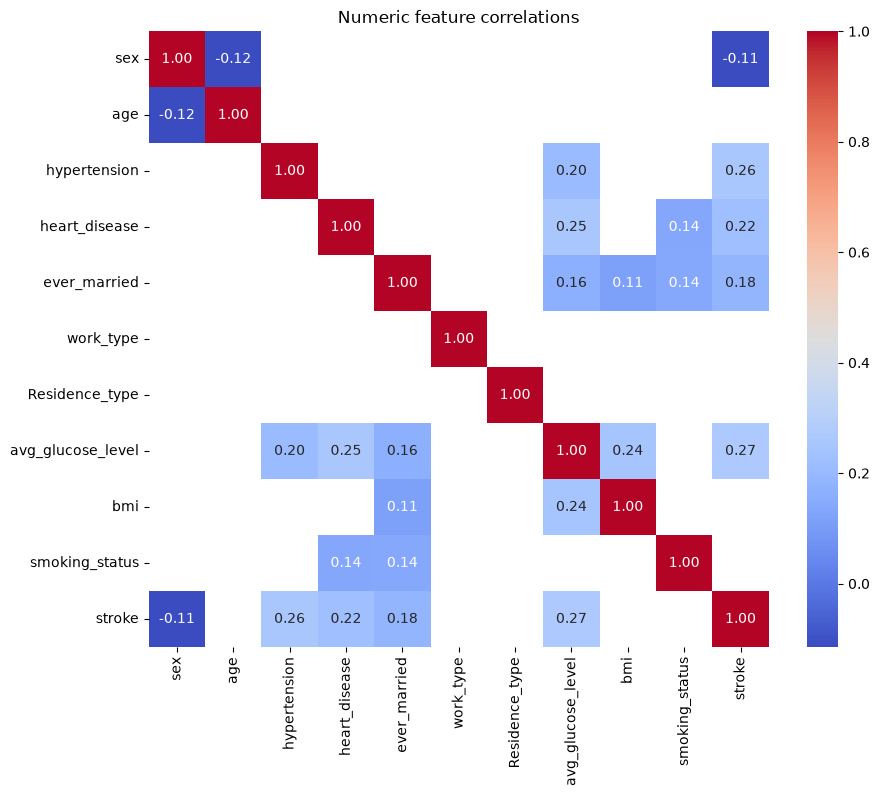

In [3]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()
threshold = 0.1
plt.figure(figsize=(10, 8))
sns.heatmap(corr[(abs(corr) > threshold) | (abs(corr) < -1 * threshold)], annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Numeric feature correlations")
plt.show()

In [4]:
corr_stroke = corr['stroke'].drop('stroke', errors='ignore')
insignificant_corr_indexes = corr_stroke[abs(corr_stroke) < threshold].index.tolist()
display(insignificant_corr_indexes)

['age', 'work_type', 'Residence_type', 'bmi', 'smoking_status']

In [5]:
#insignificant_corr_indexes.remove('bmi')
#insignificant_corr_indexes.remove('smoking_status')
#df.drop(columns=insignificant_corr_indexes, inplace=True)
#display(df.head(5))

In [6]:
print("Shape of the dataframe before removing duplicates:", df.shape)
df.drop_duplicates(inplace=True)
print("Shape of the dataframe after removing duplicates:", df.shape)

Shape of the dataframe before removing duplicates: (40910, 11)
Shape of the dataframe after removing duplicates: (40910, 11)


In [7]:
print("Size before dropping missing values:", df.shape)
df = df.dropna()
print("Size after dropping missing values:", df.shape)

Size before dropping missing values: (40910, 11)
Size after dropping missing values: (40907, 11)


array([[<Axes: title={'center': 'sex'}>, <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'hypertension'}>],
       [<Axes: title={'center': 'heart_disease'}>,
        <Axes: title={'center': 'ever_married'}>,
        <Axes: title={'center': 'work_type'}>],
       [<Axes: title={'center': 'Residence_type'}>,
        <Axes: title={'center': 'avg_glucose_level'}>,
        <Axes: title={'center': 'bmi'}>],
       [<Axes: title={'center': 'smoking_status'}>,
        <Axes: title={'center': 'stroke'}>, <Axes: >]], dtype=object)

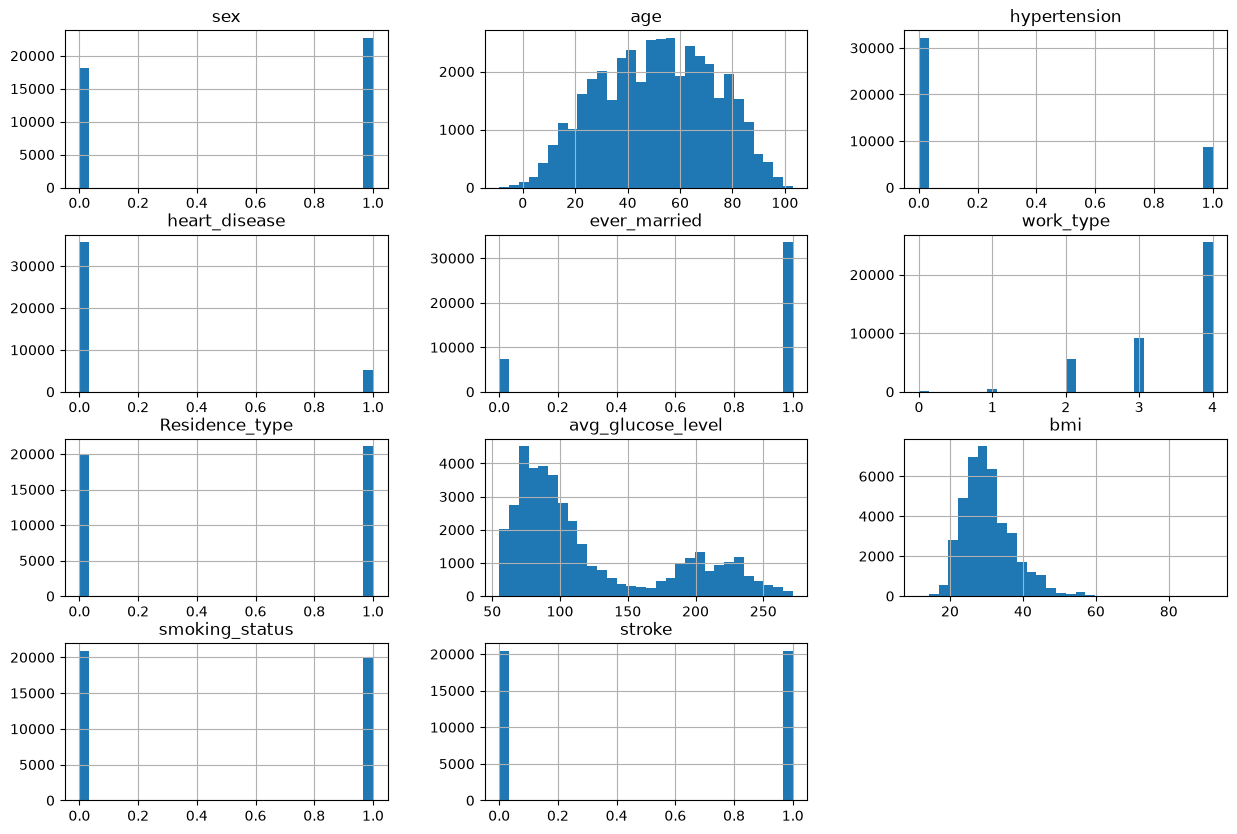

In [8]:
df.hist(bins=30, figsize=(15, 10))

In [9]:
negative_age_rows = df[df['age'] < 0]
df = df[df['age'] >= 0]
print(f"Number of rows with negative age removed: {len(negative_age_rows)}")
print(f"Number of rows left in the dataframe: {len(df)}")

Number of rows with negative age removed: 58
Number of rows left in the dataframe: 40849


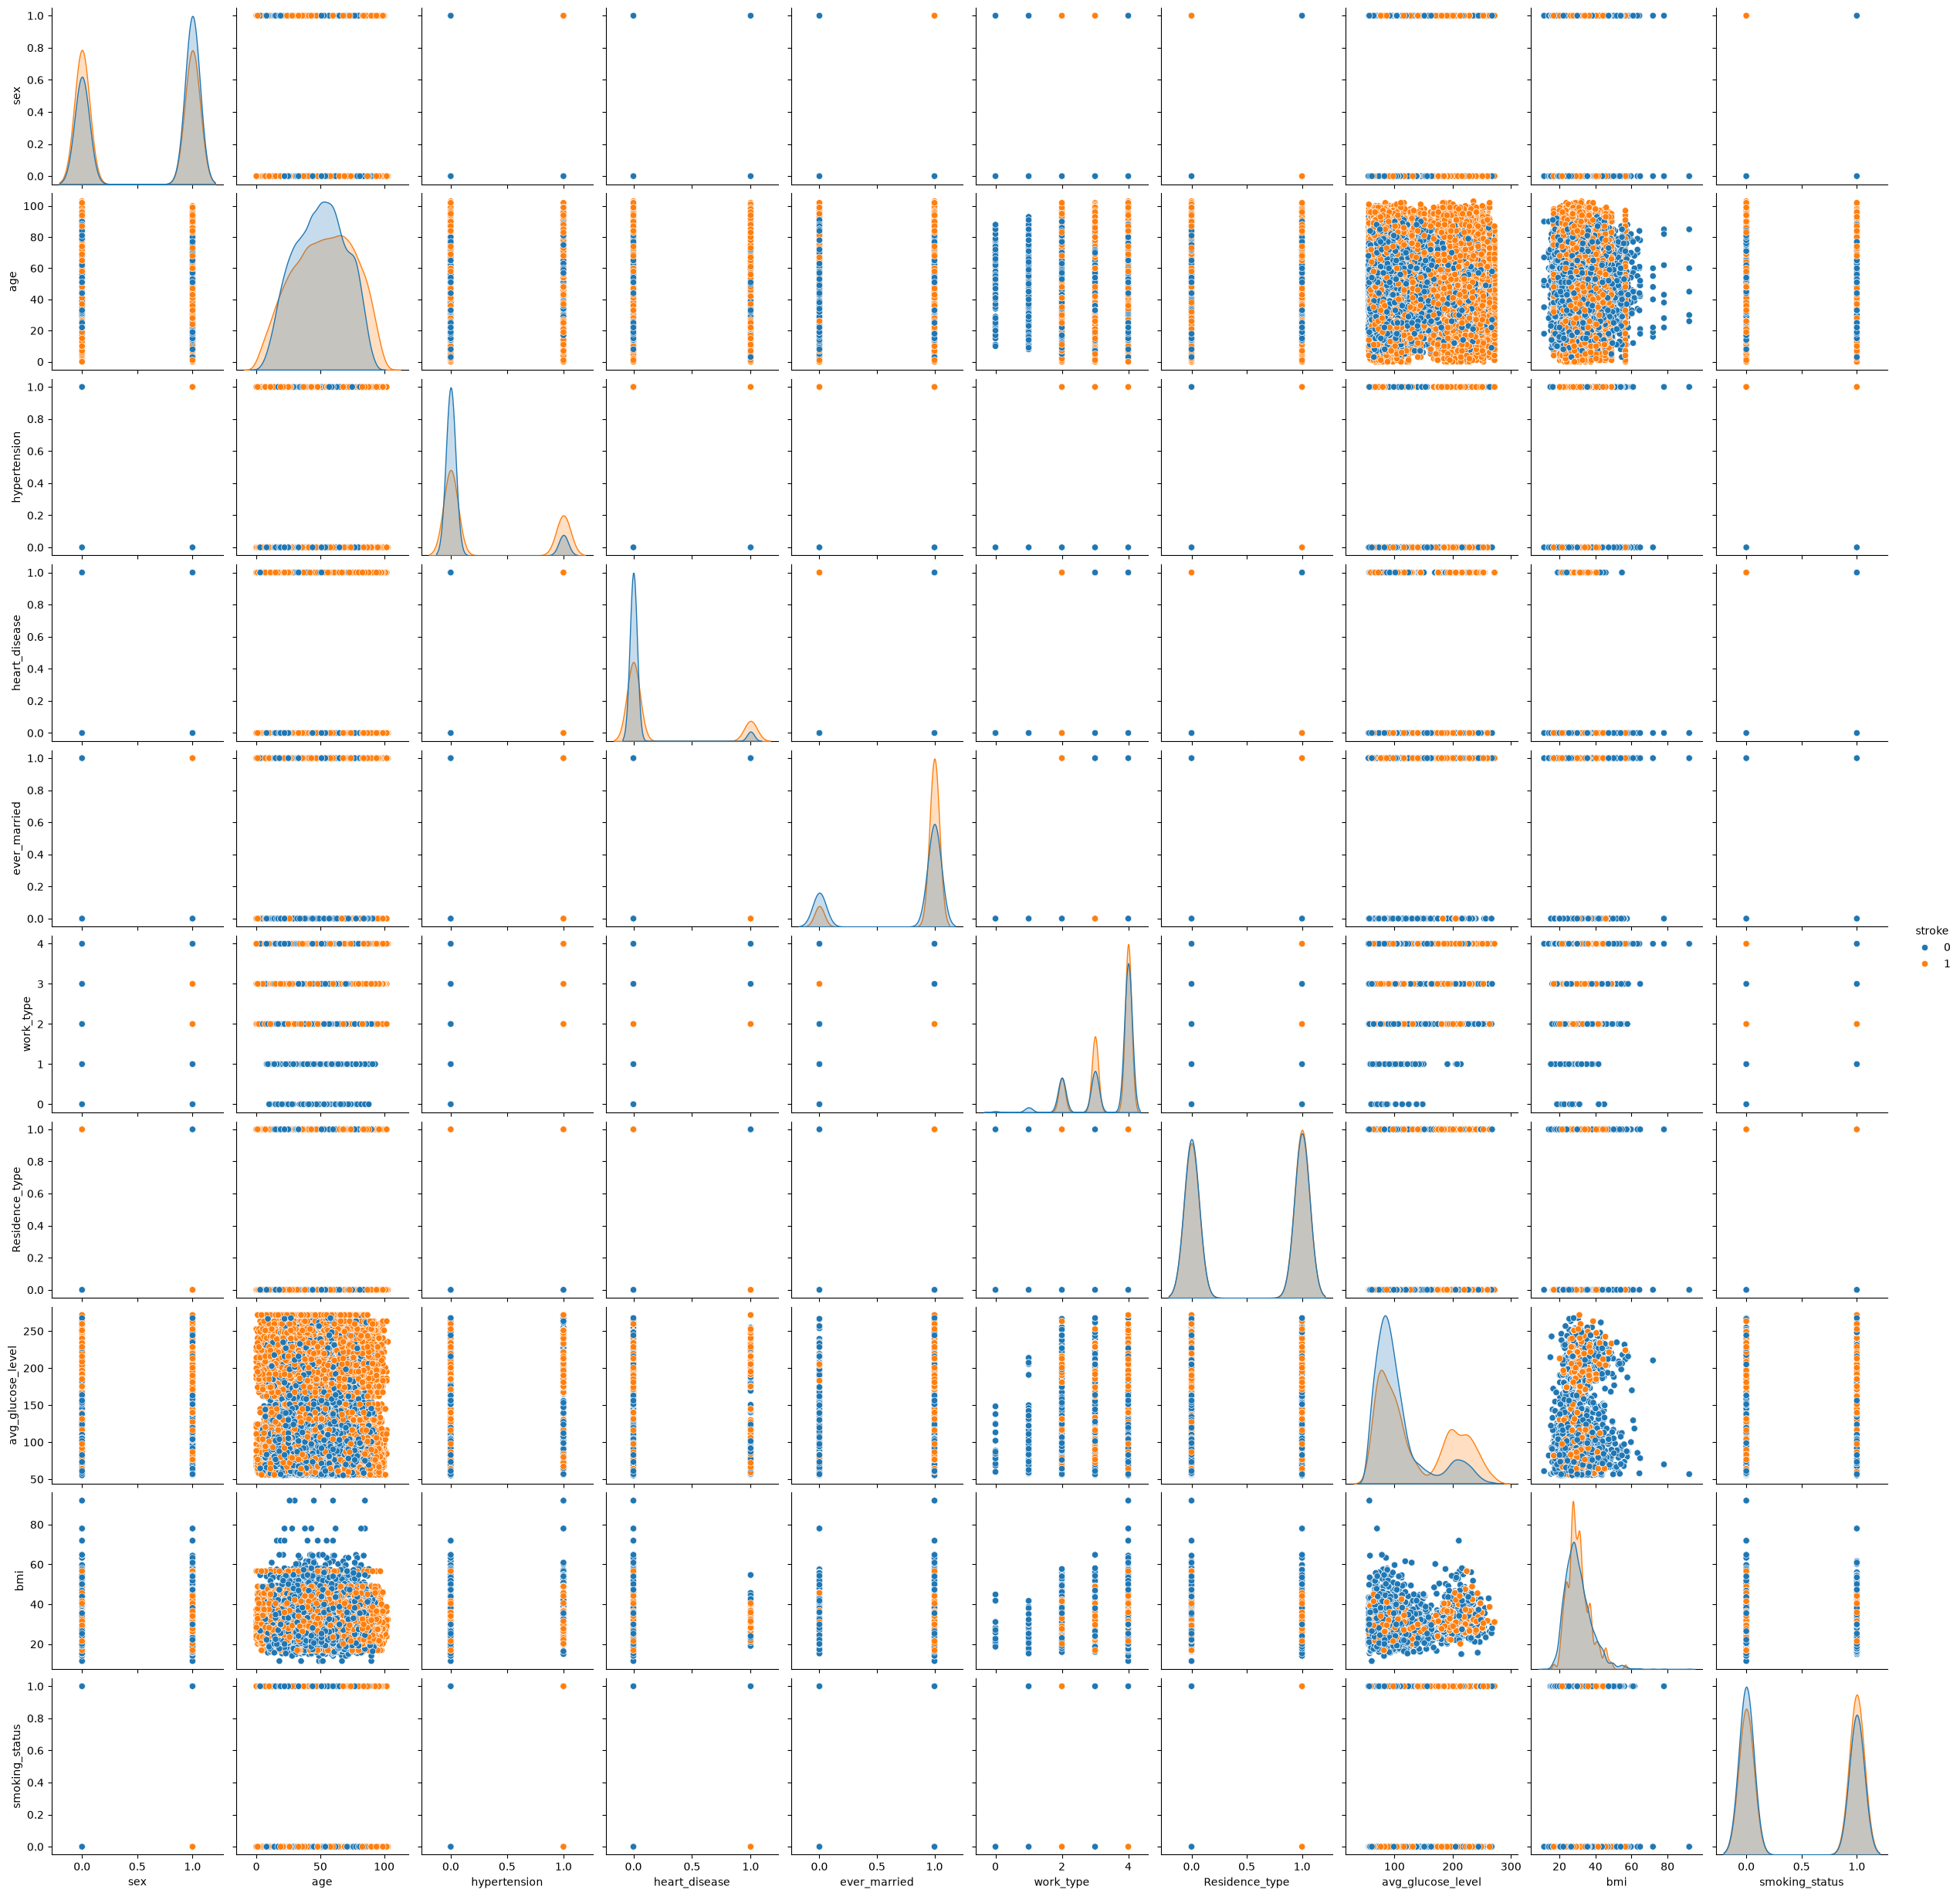

In [92]:
sns.pairplot(df, hue='stroke')
plt.show()

In [52]:
df = df.sample(frac=1, random_state=123123).reset_index(drop=True)

In [53]:
X = df.drop('stroke', axis=1)
y = df['stroke']

### Train-test split

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123123, stratify=y
)

In [55]:
print('Total dataset size:', X.shape[0])
print('Training set size:', X_train.shape[0], '({:.2f}%)'.format(X_train.shape[0] / X.shape[0] * 100))
print('Test set size:', X_test.shape[0], '({:.2f}%)'.format(X_test.shape[0] / X.shape[0] * 100))

Total dataset size: 40852
Training set size: 32681 (80.00%)
Test set size: 8171 (20.00%)


### Standardization

In [56]:
categorical_features = ['work_type']
categorical_features = [c for c in categorical_features if c in X_train.columns]
numeric_features = [c for c in X_train.columns if c not in categorical_features]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
], remainder="drop")

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed training shape: (32681, 14)
Processed test shape: (8171, 14)


## Logistic regression model

In [57]:
log_reg = LogisticRegression(
    max_iter=50000
)

### Grid search

In [58]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=123123)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("log_reg", LogisticRegression(max_iter=5000, random_state=123123))
])

param_grid = [
    {
        "log_reg__C": np.logspace(-3, 3, 15),
        "log_reg__solver": ["lbfgs"],
        "log_reg__penalty": ["l2"],
        "log_reg__class_weight": [None, "balanced"]
    },
    {
        "log_reg__C": np.logspace(-3, 3, 15),
        "log_reg__solver": ["liblinear"],
        "log_reg__penalty": ["l1", "l2"],
        "log_reg__class_weight": [None, "balanced"]
    }
  ]

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=0
 )

grid_search.fit(X_train, y_train)
print("Best cross-validation ROC-AUC:", grid_search.best_score_)
print("Best hyperparameters:", grid_search.best_params_)

Best cross-validation ROC-AUC: 0.7501981924160432
Best hyperparameters: {'log_reg__C': np.float64(0.3727593720314938), 'log_reg__class_weight': 'balanced', 'log_reg__penalty': 'l2', 'log_reg__solver': 'lbfgs'}


In [59]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["No stroke", "Stroke"]))

log_reg = best_model
print("Chosen model: Logistic Regression")
print("Final selected hyperparameters:", grid_search.best_params_)


Test ROC-AUC: 0.7651288785947641
Test accuracy: 0.7005262513768205
              precision    recall  f1-score   support

   No stroke       0.68      0.75      0.71      4090
      Stroke       0.72      0.65      0.68      4081

    accuracy                           0.70      8171
   macro avg       0.70      0.70      0.70      8171
weighted avg       0.70      0.70      0.70      8171

Chosen model: Logistic Regression
Final selected hyperparameters: {'log_reg__C': np.float64(0.3727593720314938), 'log_reg__class_weight': 'balanced', 'log_reg__penalty': 'l2', 'log_reg__solver': 'lbfgs'}


### Prediction and model evaluation

Test ROC-AUC: 0.7651288785947641
Test accuracy: 0.7005262513768205
              precision    recall  f1-score   support

   No stroke       0.68      0.75      0.71      4090
      Stroke       0.72      0.65      0.68      4081

    accuracy                           0.70      8171
   macro avg       0.70      0.70      0.70      8171
weighted avg       0.70      0.70      0.70      8171



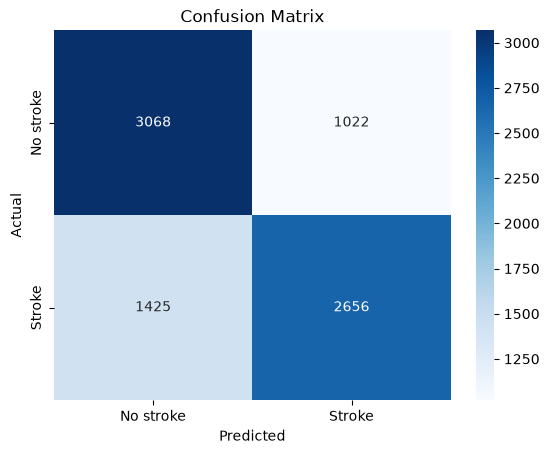

In [60]:
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["No stroke", "Stroke"]))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No stroke", "Stroke"], yticklabels=["No stroke", "Stroke"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Feature importances (coefficients):
categorical__work_type_1     -2.239443
categorical__work_type_3      1.287595
categorical__work_type_0     -1.206158
categorical__work_type_4      0.879297
categorical__work_type_2      0.687401
numeric__hypertension         0.461061
numeric__avg_glucose_level    0.435657
numeric__heart_disease        0.377153
numeric__ever_married         0.279865
numeric__sex                 -0.189868
numeric__bmi                 -0.160571
numeric__age                  0.096379
numeric__smoking_status       0.068854
numeric__Residence_type       0.054289
dtype: float64


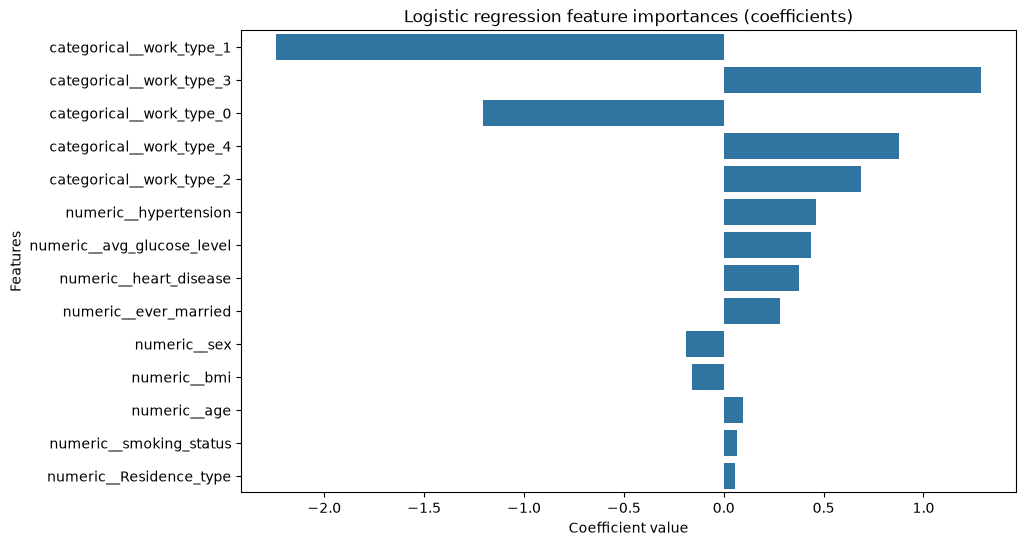

In [61]:
feature_names = log_reg.named_steps["preprocessor"].get_feature_names_out()
feature_importances = pd.Series(
    log_reg.named_steps["log_reg"].coef_[0],
    index=feature_names
).sort_values(key=abs, ascending=False)
print("Feature importances (coefficients):")
print(feature_importances.head(20))

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.head(20), y=feature_importances.head(20).index)
plt.title("Logistic regression feature importances (coefficients)")
plt.ylabel("Features")
plt.xlabel("Coefficient value")
plt.show()

## Decision tree model

In [62]:
dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=123123, class_weight="balanced"))
])

Test ROC-AUC: 1.0
Test accuracy: 1.0
              precision    recall  f1-score   support

   No stroke       1.00      1.00      1.00      4090
      Stroke       1.00      1.00      1.00      4081

    accuracy                           1.00      8171
   macro avg       1.00      1.00      1.00      8171
weighted avg       1.00      1.00      1.00      8171



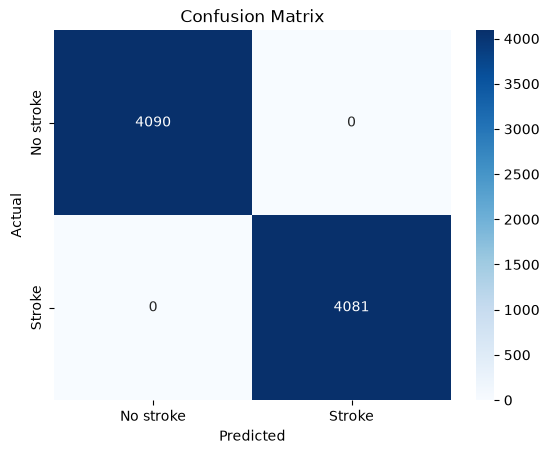

In [63]:
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)
y_proba = dt_model.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["No stroke", "Stroke"]))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No stroke", "Stroke"], yticklabels=["No stroke", "Stroke"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Feature importances:
numeric__avg_glucose_level    0.431640
numeric__bmi                  0.316907
numeric__ever_married         0.044452
numeric__hypertension         0.041622
numeric__smoking_status       0.040861
numeric__Residence_type       0.031467
categorical__work_type_3      0.026340
numeric__heart_disease        0.025606
categorical__work_type_4      0.020768
categorical__work_type_2      0.020208
numeric__age                  0.000112
numeric__sex                  0.000018
categorical__work_type_0      0.000000
categorical__work_type_1      0.000000
dtype: float64


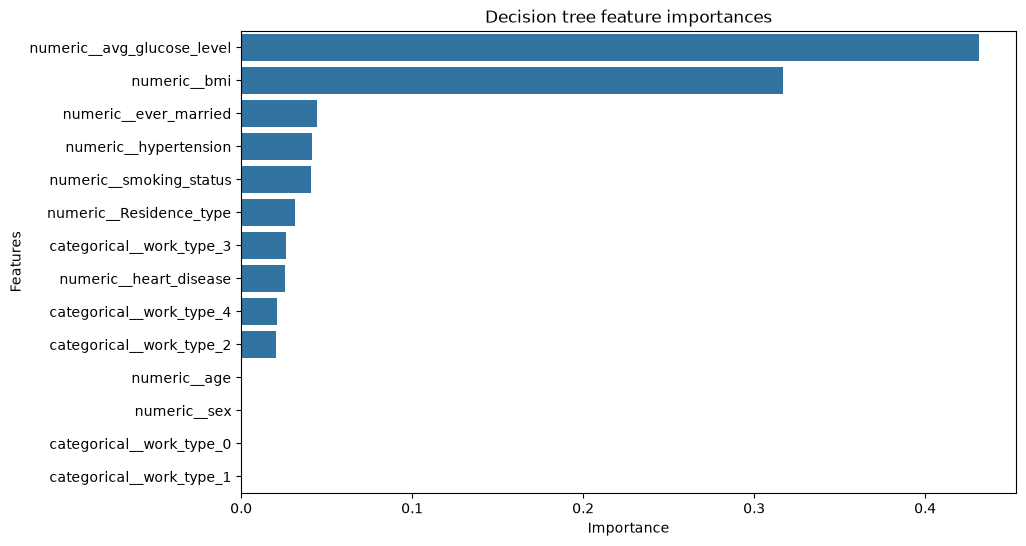

In [64]:
feature_names = dt_model.named_steps["preprocessor"].get_feature_names_out()
feature_importances = pd.Series(
    dt_model.named_steps["model"].feature_importances_,
    index=feature_names
 ).sort_values(ascending=False)
print("Feature importances:")
print(feature_importances.head(20))

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.head(20), y=feature_importances.head(20).index)
plt.title("Decision tree feature importances")
plt.ylabel("Features")
plt.xlabel("Importance")
plt.show()

## Random forest model

In [65]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=400,
        random_state=123123,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])

Test ROC-AUC: 0.9999977832749896
Test accuracy: 0.9975523191775792
              precision    recall  f1-score   support

   No stroke       1.00      1.00      1.00      4090
      Stroke       1.00      1.00      1.00      4081

    accuracy                           1.00      8171
   macro avg       1.00      1.00      1.00      8171
weighted avg       1.00      1.00      1.00      8171



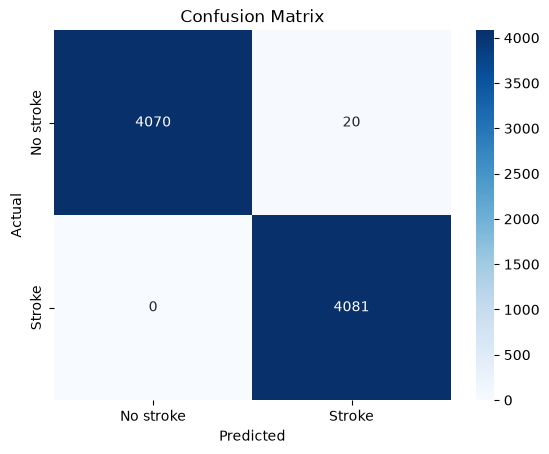

In [66]:
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["No stroke", "Stroke"]))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No stroke", "Stroke"], yticklabels=["No stroke", "Stroke"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Feature importances:
numeric__avg_glucose_level    0.389177
numeric__bmi                  0.312656
numeric__hypertension         0.055370
numeric__age                  0.054189
numeric__heart_disease        0.039541
numeric__ever_married         0.033730
numeric__smoking_status       0.030133
numeric__Residence_type       0.029872
categorical__work_type_3      0.019022
categorical__work_type_4      0.013156
categorical__work_type_2      0.011355
numeric__sex                  0.008735
categorical__work_type_1      0.002600
categorical__work_type_0      0.000466
dtype: float64


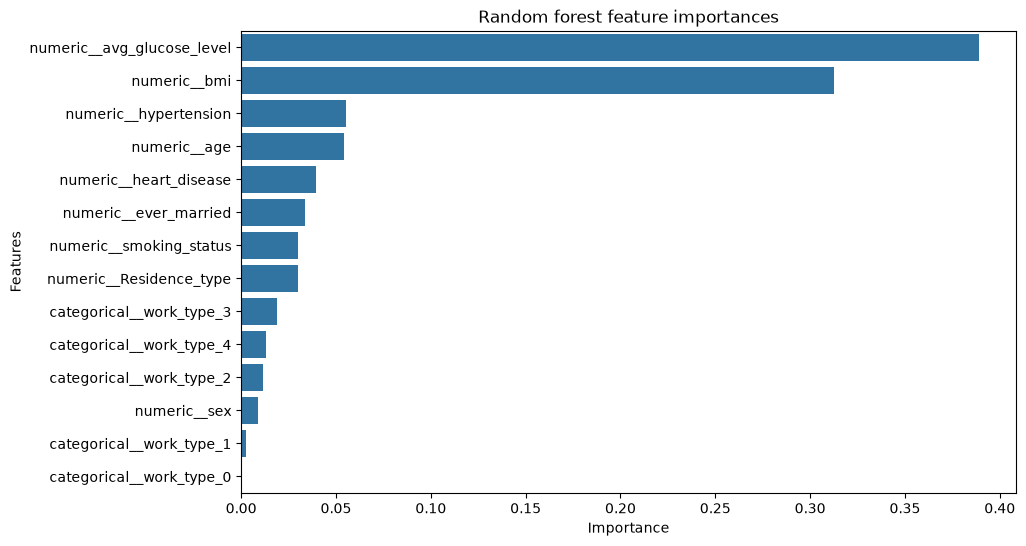

In [67]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
feature_importances = pd.Series(
    rf_model.named_steps["model"].feature_importances_,
    index=feature_names
 ).sort_values(ascending=False)
print("Feature importances:")
print(feature_importances.head(20))

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.head(20), y=feature_importances.head(20).index)
plt.title("Random forest feature importances")
plt.ylabel("Features")
plt.xlabel("Importance")
plt.show()

## K-Nearest neighbors model

In [73]:
knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

In [74]:
param_grid = {
    'model__n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan']
}
grid_search = GridSearchCV(
    knn_model,
    param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
 )
grid_search.fit(X_train, y_train)
knn_model = grid_search.best_estimator_
print("Best KNN model validation ROC-AUC:", grid_search.best_score_)
print("Best KNN model hyperparameters:", grid_search.best_params_)

Best KNN model validation ROC-AUC: 0.9804332896034669
Best KNN model hyperparameters: {'model__metric': 'manhattan', 'model__n_neighbors': 11, 'model__weights': 'distance'}


Test ROC-AUC: 0.9833498788889297
Test accuracy: 0.8981764777872966
              precision    recall  f1-score   support

   No stroke       1.00      0.80      0.89      4090
      Stroke       0.83      1.00      0.91      4081

    accuracy                           0.90      8171
   macro avg       0.91      0.90      0.90      8171
weighted avg       0.91      0.90      0.90      8171



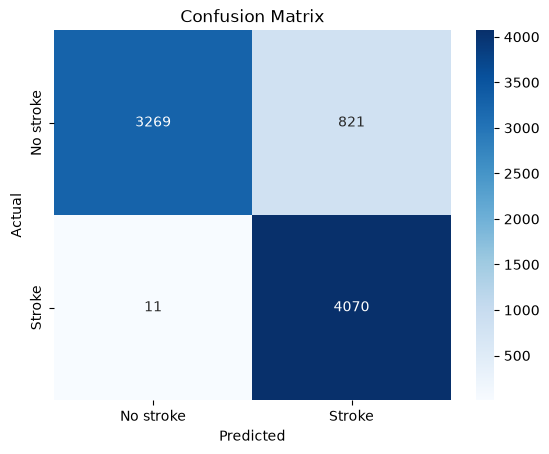

In [75]:
knn_model.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)
y_proba = knn_model.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["No stroke", "Stroke"]))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No stroke", "Stroke"], yticklabels=["No stroke", "Stroke"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [76]:
perm_result = permutation_importance(
    knn_model, X_test, y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=123123,
    n_jobs=-1
)

feature_names = X_test.columns

feature_importances = pd.Series(
    perm_result.importances_mean, index=feature_names
).sort_values(ascending=False)

print("Feature importances (permutation, mean ROC-AUC drop):")
print(feature_importances.head(20))

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.head(20), y=feature_importances.head(20).index)
plt.title("KNN feature importances (permutation importance)")
plt.ylabel("Features")
plt.xlabel("Mean decrease in ROC-AUC")
plt.show()

BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

### Naive Bayes

In [77]:
gnb_preprocessor = ColumnTransformer(
    [("numeric", numeric_transformer, numeric_features)],
    remainder="drop"
)

gnb_model = Pipeline([
    ("preprocessor", gnb_preprocessor),
    ("model", GaussianNB())
])

param_grid = {
    "model__var_smoothing": np.logspace(-12, -6, 13)
}

grid_search = GridSearchCV(
    gnb_model,
    param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_train, y_train)
gnb_model = grid_search.best_estimator_

In [78]:
y_pred = gnb_model.predict(X_test)
y_proba = gnb_model.predict_proba(X_test)[:, 1]

print("Best Naive Bayes validation ROC-AUC:", grid_search.best_score_)
print("Best Naive Bayes hyperparameters:", grid_search.best_params_)
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["No stroke", "Stroke"]))

Best Naive Bayes validation ROC-AUC: 0.7473107564961291
Best Naive Bayes hyperparameters: {'model__var_smoothing': np.float64(1e-06)}
Test ROC-AUC: 0.7620222283598213
Test accuracy: 0.6843715579488435
              precision    recall  f1-score   support

   No stroke       0.65      0.81      0.72      4090
      Stroke       0.74      0.56      0.64      4081

    accuracy                           0.68      8171
   macro avg       0.70      0.68      0.68      8171
weighted avg       0.70      0.68      0.68      8171



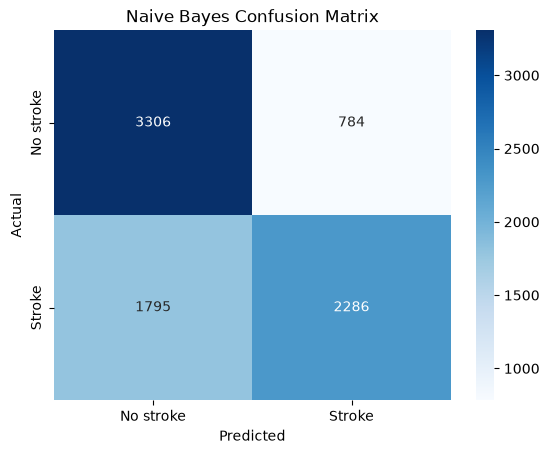

In [79]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No stroke", "Stroke"],
    yticklabels=["No stroke", "Stroke"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

## SVM

In [32]:
svm_tuning_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(probability=False, random_state=123123))
])

svm_param_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", "auto", 0.001, 0.01],
    "model__kernel": ["rbf", "linear"],
    "model__class_weight": [None, "balanced"]
}

svm_grid_search = GridSearchCV(
    estimator=svm_tuning_model,
    param_grid=svm_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=3
)

svm_grid_search.fit(X_train, y_train)

Fitting 10 folds for each of 64 candidates, totalling 640 fits


GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=123123, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['sex',
                                                                          'age',
                                                                          'hypertension',
                                                                          'heart_disease',
                                                                          'ever_married',
                                                                          'Residence_type',
                                                                          'avg_glucose_level',...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['work_type'])])),
                                       ('model', SVC(random_state=123123))]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10, 100],
                         'model__class_weight': [None, 'balanced'],
                         'model__gamma': ['scale', 'auto', 0.001, 0.01],
                         'model__kernel': ['rbf', 'linear']},
             scoring='roc_auc', verbose=3)

In [33]:
best_svm_params = {
    parameter_name.removeprefix("model__"): value
    for parameter_name, value in svm_grid_search.best_params_.items()
}
svm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(probability=True, random_state=123123, **best_svm_params))
])
svm_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['sex', 'age', 'hypertension',
                                                   'heart_disease',
                                                   'ever_married',
                                                   'Residence_type',
                                                   'avg_glucose_level', 'bmi',
                                                   'smoking_status']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['work_type'])])),
                ('model', SVC(C=100, probability=True, random_state=123123))])

In [34]:
y_pred = svm_model.predict(X_test)
y_proba = svm_model.predict_proba(X_test)[:, 1]

print("Best SVM validation ROC-AUC:", svm_grid_search.best_score_)
print("Best SVM hyperparameters:", svm_grid_search.best_params_)
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["No stroke", "Stroke"]))

Best SVM validation ROC-AUC: 0.9103502329144156
Best SVM hyperparameters: {'model__C': 100, 'model__class_weight': None, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Test ROC-AUC: 0.9123554039487867
Test accuracy: 0.8452701051087753
              precision    recall  f1-score   support

   No stroke       0.87      0.82      0.84      4090
      Stroke       0.83      0.87      0.85      4092

    accuracy                           0.85      8182
   macro avg       0.85      0.85      0.85      8182
weighted avg       0.85      0.85      0.85      8182



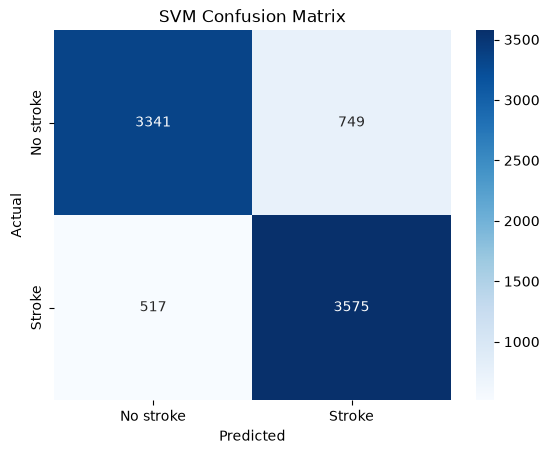

In [35]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No stroke", "Stroke"],
    yticklabels=["No stroke", "Stroke"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

## XGBoost

In [80]:
xgb_tuning_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=123123,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

xgb_param_grid = {
    "model__n_estimators": [100, 200, 400],
    "model__max_depth": [3, 4, 6],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__scale_pos_weight": [1, (y_train == 0).sum() / (y_train == 1).sum()]
}

xgb_grid_search = GridSearchCV(
    estimator=xgb_tuning_model,
    param_grid=xgb_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=0
)

xgb_grid_search.fit(X_train, y_train)
xgb_model = xgb_grid_search.best_estimator_
print("Best XGBoost validation ROC-AUC:", xgb_grid_search.best_score_)
print("Best XGBoost hyperparameters:", xgb_grid_search.best_params_)

Best XGBoost validation ROC-AUC: 0.9999988576573662
Best XGBoost hyperparameters: {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 400, 'model__scale_pos_weight': np.float64(1.0023895594632681), 'model__subsample': 0.8}


Test ROC-AUC: 1.0
Test accuracy: 0.9996328478766369
              precision    recall  f1-score   support

   No stroke       1.00      1.00      1.00      4090
      Stroke       1.00      1.00      1.00      4081

    accuracy                           1.00      8171
   macro avg       1.00      1.00      1.00      8171
weighted avg       1.00      1.00      1.00      8171



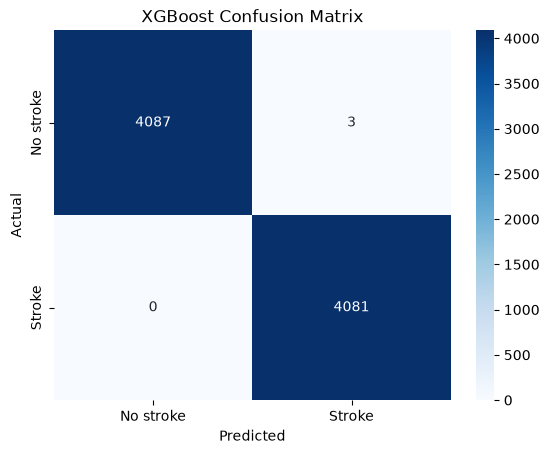

In [81]:
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["No stroke", "Stroke"]))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No stroke", "Stroke"], yticklabels=["No stroke", "Stroke"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

Feature importances:
numeric__ever_married         0.138479
numeric__hypertension         0.094801
numeric__heart_disease        0.093810
categorical__work_type_3      0.075955
categorical__work_type_1      0.075016
numeric__avg_glucose_level    0.074543
categorical__work_type_2      0.066609
numeric__age                  0.062538
numeric__sex                  0.062483
numeric__smoking_status       0.062214
numeric__bmi                  0.060024
numeric__Residence_type       0.059256
categorical__work_type_4      0.059067
categorical__work_type_0      0.015204
dtype: float32


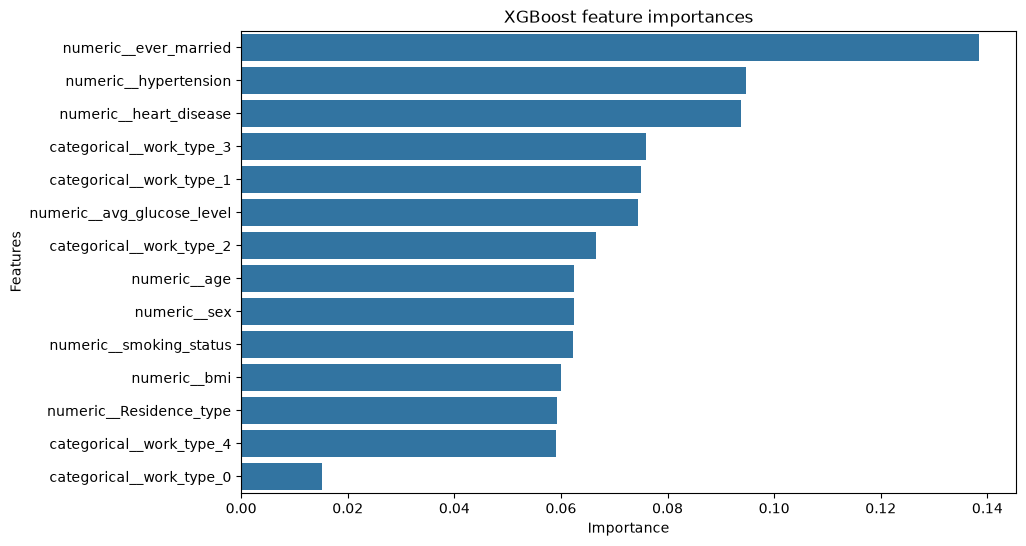

In [82]:
feature_names = xgb_model.named_steps["preprocessor"].get_feature_names_out()
feature_importances = pd.Series(
    xgb_model.named_steps["model"].feature_importances_,
    index=feature_names
).sort_values(ascending=False)
print("Feature importances:")
print(feature_importances.head(20))

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.head(20), y=feature_importances.head(20).index)
plt.title("XGBoost feature importances")
plt.ylabel("Features")
plt.xlabel("Importance")
plt.show()

## ADA Boost

In [88]:
ada_tuning_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", AdaBoostClassifier(random_state=123123))
])

ada_param_grid = {
    "model__n_estimators": [50, 100, 200, 400, 600],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.5, 0.7, 1.0]
}

ada_grid_search = GridSearchCV(
    estimator=ada_tuning_model,
    param_grid=ada_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=0
)

ada_grid_search.fit(X_train, y_train)
ada_model = ada_grid_search.best_estimator_
print("Best AdaBoost validation ROC-AUC:", ada_grid_search.best_score_)
print("Best AdaBoost hyperparameters:", ada_grid_search.best_params_)

Best AdaBoost validation ROC-AUC: 0.7816029149752844
Best AdaBoost hyperparameters: {'model__learning_rate': 1.0, 'model__n_estimators': 600}


Test ROC-AUC: 0.7943828487792136
Test accuracy: 0.7083588300085669
              precision    recall  f1-score   support

   No stroke       0.68      0.77      0.73      4090
      Stroke       0.74      0.64      0.69      4081

    accuracy                           0.71      8171
   macro avg       0.71      0.71      0.71      8171
weighted avg       0.71      0.71      0.71      8171



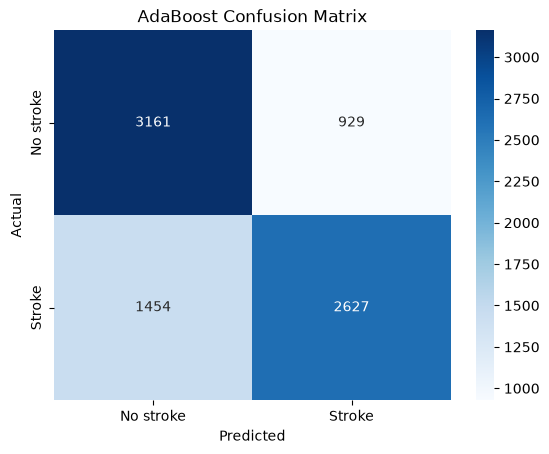

In [89]:
y_pred = ada_model.predict(X_test)
y_proba = ada_model.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["No stroke", "Stroke"]))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No stroke", "Stroke"], yticklabels=["No stroke", "Stroke"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("AdaBoost Confusion Matrix")
plt.show()

Feature importances:
numeric__age                  0.242734
numeric__bmi                  0.214273
numeric__avg_glucose_level    0.177531
categorical__work_type_1      0.166913
numeric__heart_disease        0.060673
numeric__hypertension         0.058784
numeric__ever_married         0.028586
categorical__work_type_0      0.017212
numeric__sex                  0.013810
categorical__work_type_3      0.012307
numeric__smoking_status       0.007176
numeric__Residence_type       0.000000
categorical__work_type_2      0.000000
categorical__work_type_4      0.000000
dtype: float64


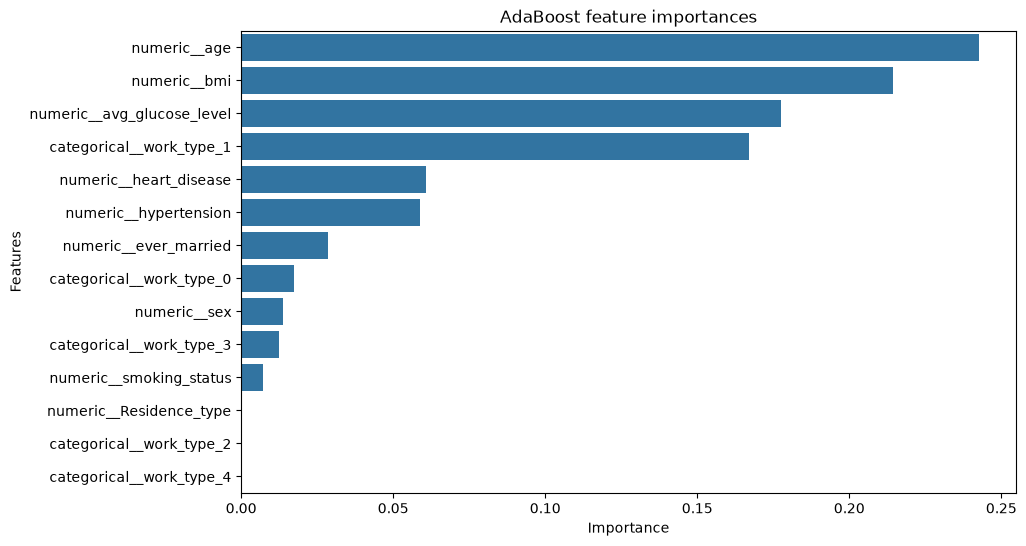

In [90]:
feature_names = ada_model.named_steps["preprocessor"].get_feature_names_out()
feature_importances = pd.Series(
    ada_model.named_steps["model"].feature_importances_,
    index=feature_names
).sort_values(ascending=False)
print("Feature importances:")
print(feature_importances.head(20))

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.head(20), y=feature_importances.head(20).index)
plt.title("AdaBoost feature importances")
plt.ylabel("Features")
plt.xlabel("Importance")
plt.show()